# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 65.0 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
data_set_shape = df_data.shape
print("Shape of the df_data {}".format(data_set_shape))

print("No of rows {}".format(data_set_shape[0]))
print("No of columns {}".format(data_set_shape[1]))

df_data.info()

Shape of the df_data (4324, 9)
No of rows 4324
No of columns 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [7]:
print("Are there any duplicates: {}", df_data.duplicated().any())
print("Are there any NaN values: {}", df_data.isna().any().any())

Are there any duplicates: {} False
Are there any NaN values: {} True


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [118]:
# cleaned_data = df_data.dropna(axis=0)
cleaned_data = df_data.copy()

In [119]:
print("Are there any duplicates:", cleaned_data.duplicated().any())

Are there any duplicates: False


## Descriptive Statistics

In [120]:
cleaned_data.describe()

,Unnamed: 0.1,Unnamed: 0
count,"4,324.00","4,324.00"
mean,"2,161.50","2,161.50"
std,"1,248.38","1,248.38"
min,0.00,0.00
25%,"1,080.75","1,080.75"
50%,"2,161.50","2,161.50"
75%,"3,242.25","3,242.25"
max,"4,323.00","4,323.00"


In [121]:
cleaned_data.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], inplace=True)

# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [122]:
launches_per_company = cleaned_data.groupby("Organisation").count()
launches_per_company

,Location,Date,Detail,Rocket_Status,Price,Mission_Status
Organisation,,,,,,
AEB,3,3,3,3,0,3
AMBA,8,8,8,8,0,8
ASI,9,9,9,9,0,9
Arianespace,279,279,279,279,96,279
Arm??e de l'Air,4,4,4,4,0,4
Blue Origin,12,12,12,12,0,12
Boeing,136,136,136,136,7,136
CASC,251,251,251,251,158,251
CASIC,5,5,5,5,0,5


In [123]:
fig = px.bar(launches_per_company, x=launches_per_company.index, y="Date")
fig.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [124]:
cleaned_data['Rocket_Status_Active'] = cleaned_data["Rocket_Status"].apply(lambda x :1 if x == "StatusActive" else 0)

In [20]:
retired_count = cleaned_data['Rocket_Status'].value_counts()
retired_count

,count
Rocket_Status,
StatusActive,586
StatusRetired,378


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [125]:
success_failure_counts = cleaned_data['Mission_Status'].value_counts()
success_failure_counts

,count
Mission_Status,
Success,3879
Failure,339
Partial Failure,102
Prelaunch Failure,4


# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [126]:
cleaned_data['Price'] = pd.to_numeric(cleaned_data['Price'], errors='coerce')

In [32]:
df = cleaned_data.Price
fig = px.histogram(df, x="Price", title="Distribution of Rocket Launch Prices (USD Millions)")
fig.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [128]:
cleaned_data["Country"] = cleaned_data["Location"].apply(lambda x: x.split(',')[-1].strip())

def standardize_country(country_name):
    if 'Russia' in country_name or 'Baikonur Cosmodrome' in country_name or 'Barents Sea' in country_name:
        return 'Russian Federation'
    elif 'New Mexico' in country_name or 'USA' in country_name or 'Pacific Missile Range Facility' in country_name or 'Gran Canaria' in country_name:
        return 'USA'
    elif 'Yellow Sea' in country_name:
        return 'China'
    elif 'Shahrud Missile Test Site' in country_name:
        return 'Iran'
    else:
        return country_name

cleaned_data['Country'] = cleaned_data['Country'].apply(standardize_country)


country_to_alpha3 = {}

for country_code in countries:
    country_to_alpha3[country_code.name] = country_code.alpha3

def get_alpha3(country_name):
  try:
    return country_to_alpha3[country_name]
  except KeyError:
        if country_name == 'Russian Federation':
            return 'RUS'
        elif country_name == 'North Korea':
            return 'PRK'
        elif country_name == 'South Korea':
            return 'KOR'
        elif country_name == 'Iran':
            return 'IRN'
        elif country_name == 'England':
            return 'GBR'
        return country_name


cleaned_data["Country_alpha3"] = cleaned_data["Country"].apply(get_alpha3)

print(cleaned_data[['Location', 'Country', 'Country_alpha3']].head())

                                            Location     Country  \
0         LC-39A, Kennedy Space Center, Florida, USA         USA   
1  Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...       China   
2                      Pad A, Boca Chica, Texas, USA         USA   
3       Site 200/39, Baikonur Cosmodrome, Kazakhstan  Kazakhstan   
4           SLC-41, Cape Canaveral AFS, Florida, USA         USA   

  Country_alpha3  
0            USA  
1            CHN  
2            USA  
3            KAZ  
4            USA  


In [130]:

launches_by_country = cleaned_data.groupby('Country_alpha3').size().reset_index(name='Number of Launches')

fig = px.choropleth(
    launches_by_country,
    locations='Country_alpha3',
    color='Number of Launches',
    hover_name=launches_by_country['Country_alpha3'].map({v: k for k, v in country_to_alpha3.items()}), # Map back to full name for hover
    color_continuous_scale='matter',
    title='Number of Space Mission Launches by Country'
)
fig.show()

This choropleth map visualizes the geographical distribution of space mission failures. By looking at the intensity of the colors, you can quickly identify countries that have had a higher number of mission failures.

# Use a Choropleth Map to Show the Number of Failures by Country


In [131]:
failed_missions = cleaned_data[cleaned_data['Mission_Status'].str.contains('Failure', na=False)]

failures_by_country = failed_missions.groupby('Country_alpha3').size().reset_index(name='Number of Failures')


fig = px.choropleth(
    failures_by_country,
    locations='Country_alpha3',
    color='Number of Failures',
    hover_name=failures_by_country['Country_alpha3'].map({v: k for k, v in country_to_alpha3.items()}),
    color_continuous_scale='matter',
    title='Number of Space Mission Failures by Country'
)
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [132]:
fig = px.sunburst(cleaned_data,
                  path=['Country', 'Organisation', 'Mission_Status'],
                  title='Space Missions by Country, Organisation, and Mission Status',
                  hover_name='Organisation')
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [133]:
total_amount = cleaned_data.groupby('Organisation')['Price'].sum().reset_index()
total_amount

,Organisation,Price
0,AEB,0.00
1,AMBA,0.00
2,ASI,0.00
3,Arianespace,"16,345.00"
4,Arm??e de l'Air,0.00
5,Blue Origin,0.00
6,Boeing,"1,241.00"
7,CASC,"6,340.26"
8,CASIC,0.00
9,CECLES,0.00


Analyse the Amount of Money Spent by Organisation per Launch

# Chart the Number of Launches per Year

In [134]:

cleaned_data['Date'] = pd.to_datetime(cleaned_data['Date'], format='mixed', utc=True)


launches_per_year = cleaned_data['Date'].dt.year.value_counts().sort_index()

print(launches_per_year)

Date
1957      3
1958     28
1959     20
1960     39
1961     52
       ... 
2016     90
2017     92
2018    117
2019    109
2020     63
Name: count, Length: 64, dtype: int64


In [60]:
figure = px.bar(launches_per_year, x=launches_per_year.index, y=launches_per_year.values)
figure.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [135]:
df_temp = cleaned_data.set_index('Date')
launches_per_month = df_temp.resample('MS').size()

rolling_avg = launches_per_month.rolling(window=12).mean()

peak_month = launches_per_month.idxmax()
peak_value = launches_per_month.max()

In [136]:
fig = px.bar(launches_per_month, x=launches_per_month.index, y=launches_per_month)
print(peak_month, peak_value)

1971-12-01 00:00:00+00:00 18


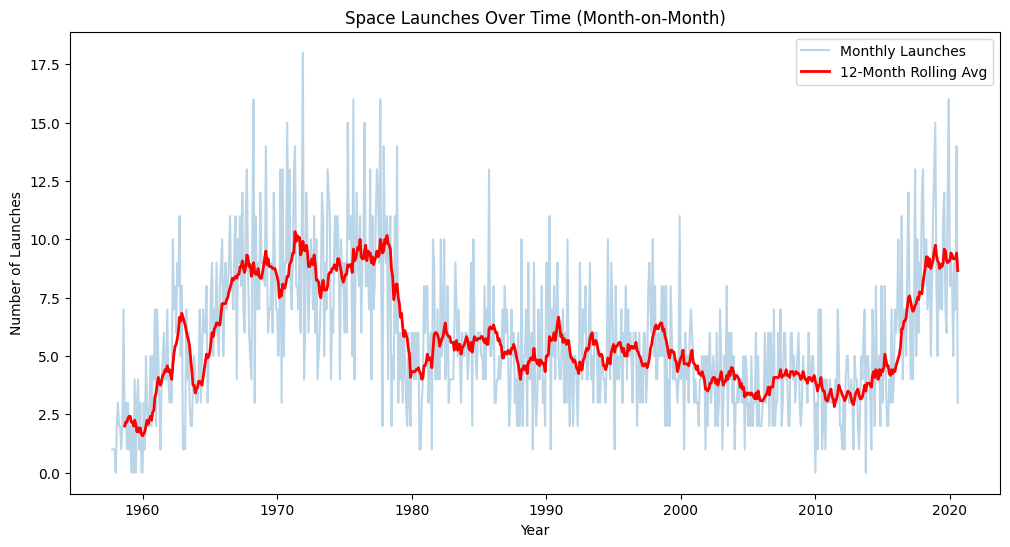

In [137]:
plt.figure(figsize=(12, 6))
plt.plot(launches_per_month.index, launches_per_month.values, label='Monthly Launches', alpha=0.3)
plt.plot(launches_per_month.index, rolling_avg, label='12-Month Rolling Avg', color='red', linewidth=2)

plt.title('Space Launches Over Time (Month-on-Month)')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.legend()
plt.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [138]:

monthly_stats = launches_per_month.groupby(launches_per_month.index.month).sum()

import calendar
monthly_stats.index = [calendar.month_name[m] for m in monthly_stats.index]


most_popular = monthly_stats.idxmax()
least_popular = monthly_stats.idxmin()

print(f"Most Popular: {most_popular} ({monthly_stats.max()} launches)")
print(f"Least Popular: {least_popular} ({monthly_stats.min()} launches)")

Most Popular: December (450 launches)
Least Popular: January (268 launches)


# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [139]:
avg_price_over_time = cleaned_data.groupby(cleaned_data['Date'].dt.year)['Price'].mean()
avg_price_over_time = avg_price_over_time.reset_index()
avg_price_over_time.head()

,Date,Price
0,1957,NaN
1,1958,NaN
2,1959,NaN
3,1960,NaN
4,1961,NaN


In [140]:
line_graph = px.line(
    avg_price_over_time,
    x='Date',
    y='Price',
    title='Average Rocket Launch Price Over Time'
)


line_graph.update_traces(connectgaps=True)

line_graph.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [141]:
top_10_organisations = cleaned_data['Organisation'].value_counts().head(10).index
top_10_organisations


Index(['RVSN USSR', 'Arianespace', 'General Dynamics', 'CASC', 'NASA',
       'VKS RF', 'US Air Force', 'ULA', 'Boeing', 'Martin Marietta'],
      dtype='object', name='Organisation')

In [142]:
df_top_10 = cleaned_data[cleaned_data['Organisation'].isin(top_10_organisations)]
evolution_df = df_top_10.groupby([df_top_10['Date'].dt.year, 'Organisation']).size().reset_index(name='Launches')
evolution_df

,Date,Organisation,Launches
0,1957,RVSN USSR,2
1,1958,NASA,2
2,1958,RVSN USSR,5
3,1958,US Air Force,2
4,1959,General Dynamics,1
...,...,...,...
318,2019,VKS RF,8
319,2020,Arianespace,4
320,2020,CASC,19
321,2020,ULA,4


In [143]:
fig = px.line(evolution_df,
              x='Date',
              y='Launches',
              color='Organisation',
              title='The Shift in Launch Dominance (Top 10)')
fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [144]:
cold_war_mask = (cleaned_data['Date'].dt.year > 1957) & (cleaned_data['Date'].dt.year <= 1991)
cold_war_df = cleaned_data[cold_war_mask].copy()

cold_war_df.Country_alpha3.value_counts()

,count
Country_alpha3,
RUS,1188
USA,661
KAZ,580
FRA,61
JPN,52
CHN,38
KEN,9
IND,7
AUS,6


In [146]:
mappings={
    'USA': 'USA',
    'RUS':'USSR',
    'KAZ':'USSR'
}


cold_war_df['Nation'] = cold_war_df['Country_alpha3'].map(mappings)

# cold_war_df['Nation'].value_counts()
cold_war_df.dropna(subset=['Nation'])

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Rocket_Status_Active,Country,Country_alpha3,Nation
1718,RVSN USSR,"Site 175/58, Baikonur Cosmodrome, Kazakhstan",1991-12-20 00:00:00+00:00,Rokot/Briz K | GVM Demo Flight,StatusRetired,NaN,Success,0,Kazakhstan,KAZ,USSR
1719,Yuzhmash,"Site 32/2, Plesetsk Cosmodrome, Russia",1991-12-18 03:54:00+00:00,Tsyklon-3 | Intercosmos 25 & Magion 3,StatusRetired,NaN,Success,0,Russian Federation,RUS,USSR
1721,General Dynamics,"SLC-36B, Cape Canaveral AFS, Florida, USA",1991-12-07 22:47:00+00:00,Atlas II | Eutelsat 2F3,StatusRetired,NaN,Success,0,USA,USA,USA
1722,General Dynamics,"SLC-3W, Vandenberg AFB, California, USA",1991-11-28 13:23:00+00:00,Atlas-E/F Star-37S-ISS | DMSP F-11,StatusRetired,NaN,Success,0,USA,USA,USA
1723,RVSN USSR,"Site 133/3, Plesetsk Cosmodrome, Russia",1991-11-27 03:30:00+00:00,Cosmos-3M (11K65M) | Cosmos 2173,StatusRetired,NaN,Success,0,Russian Federation,RUS,USSR
...,...,...,...,...,...,...,...,...,...,...,...
4316,AMBA,"LC-5, Cape Canaveral AFS, Florida, USA",1958-03-26 17:38:00+00:00,Juno I | Explorer 3,StatusRetired,NaN,Success,0,USA,USA,USA
4317,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-03-17 12:15:00+00:00,Vanguard | Vanguard 1,StatusRetired,NaN,Success,0,USA,USA,USA
4318,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-03-05 18:27:00+00:00,Juno I | Explorer 2,StatusRetired,NaN,Failure,0,USA,USA,USA
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,0,USA,USA,USA


In [147]:
race_counts = cold_war_df.groupby(['Nation', cold_war_df["Date"].dt.year]).size().reset_index(name='Launches')

race_counts

,Nation,Date,Launches
0,USA,1958,23
1,USA,1959,16
2,USA,1960,30
3,USA,1961,43
4,USA,1962,60
...,...,...,...
63,USSR,1987,42
64,USSR,1988,36
65,USSR,1989,26
66,USSR,1990,37


In [148]:
fig = px.line(race_counts, x='Date', y='Launches', color='Nation',
              title='The Cold War Space Race: Total Launches (1957-1991)',
              color_discrete_map={'USA': 'blue', 'USSR': 'red'})
fig.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [149]:
launches_totals = cold_war_df['Nation'].value_counts().reset_index()
launches_totals.columns = ['Nation', 'Count']

In [150]:
pie_plot = px.pie(launches_totals, values='Count', names='Nation', title='Total Launches of the USSR and the USA')
pie_plot.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [154]:
year_on_to_year = cold_war_df.groupby([cold_war_df.Date.dt.year, 'Nation']).size().reset_index(name='Launches')
year_on_to_year

,Date,Nation,Launches
0,1958,USA,23
1,1958,USSR,5
2,1959,USA,16
3,1959,USSR,4
4,1960,USA,30
...,...,...,...
63,1989,USSR,26
64,1990,USA,26
65,1990,USSR,37
66,1991,USA,18


In [156]:
fig = px.line(year_on_to_year,
              x='Date',
              y='Launches',
              color='Nation',
              title='Total Number of Launches Year-on-Year: USA vs. USSR',
              color_discrete_map={'USA': 'blue', 'USSR': 'red'})

fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [158]:
failed_mission = cold_war_df[cold_war_df['Mission_Status'].str.contains('Failure', na=False)]

In [160]:
year_on_year_failed = failed_mission.groupby([failed_mission.Date.dt.year, 'Nation']).size().reset_index(name="Launches")
fig = px.line(year_on_year_failed,
              x='Date',
              y='Launches',
              color='Nation',
              title='Total Number of Failed Launches Year-on-Year: USA vs. USSR',
              color_discrete_map={'USA': 'blue', 'USSR': 'red'})

fig.show()


## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [161]:
cold_war_df['Is_Failure'] = cold_war_df['Mission_Status'].str.contains('Failure', na=False).astype(int)

In [163]:
failure_rate_df = cold_war_df.groupby([cold_war_df.Date.dt.year, 'Nation'])['Is_Failure'].mean().reset_index()

failure_rate_df.columns = ['Date', 'Nation', 'Failure_Rate_Percentage']
failure_rate_df['Failure_Rate_Percentage']*=100

failure_rate_df

,Date,Nation,Failure_Rate_Percentage
0,1958,USA,78.26
1,1958,USSR,80.00
2,1959,USA,62.50
3,1959,USSR,50.00
4,1960,USA,46.67
...,...,...,...
63,1989,USSR,3.85
64,1990,USA,3.85
65,1990,USSR,5.41
66,1991,USA,11.11


In [165]:
fig = px.line(failure_rate_df,
              x='Date',
              y='Failure_Rate_Percentage',
              color='Nation',
              title='Launch Failure Rate Over Time (%)',
              color_discrete_map={'USA': 'blue', 'USSR': 'red'},
              markers=True)

fig.update_layout(yaxis_title='Failure Rate (%)', hovermode='x unified')
fig.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [169]:
leading_countries_df = cleaned_data.groupby([cleaned_data.Date.dt.year, 'Country_alpha3']).size().reset_index(name='Launches')
total_per_year_total = leading_countries_df.loc[leading_countries_df.groupby('Date')['Launches'].idxmax()]
total_per_year_total

,Date,Country_alpha3,Launches
0,1957,KAZ,2
3,1958,USA,23
5,1959,USA,16
7,1960,USA,30
10,1961,USA,43
...,...,...,...
391,2016,USA,27
400,2017,USA,30
401,2018,CHN,39
409,2019,CHN,34


In [172]:

success_only = cleaned_data[cleaned_data['Mission_Status'] == 'Success']

leading_success_df = success_only.groupby([success_only.Date.dt.year, 'Country_alpha3']).size().reset_index(name='Successes')
top_per_year_success = leading_success_df.loc[leading_success_df.groupby('Date')['Successes'].idxmax()]

comparison = total_per_year_total.merge(top_per_year_success, on='Date', suffixes=('_Total', '_Success'))


swaps = comparison[comparison['Country_alpha3_Total'] != comparison['Country_alpha3_Success']]
print(swaps)

    Date Country_alpha3_Total  Launches Country_alpha3_Success  Successes
10  1967                  KAZ        38                    RUS         33
11  1968                  KAZ        40                    RUS         37
36  1993                  USA        24                    RUS         21
63  2020                  CHN        22                    USA         20


# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [173]:
year_on_year_org = cleaned_data.groupby([cleaned_data['Date'].dt.year,'Organisation']).size().reset_index(name='Launches')
year_on_year_org

,Date,Organisation,Launches
0,1957,RVSN USSR,2
1,1957,US Navy,1
2,1958,AMBA,7
3,1958,NASA,2
4,1958,RVSN USSR,5
...,...,...,...
658,2020,Roscosmos,4
659,2020,SpaceX,14
660,2020,ULA,4
661,2020,VKS RF,3


In [174]:
dominant_players = year_on_year_org.loc[year_on_year_org.groupby('Date')['Launches'].idxmax()]
dominant_players

,Date,Organisation,Launches
0,1957,RVSN USSR,2
6,1958,US Navy,12
10,1959,US Air Force,10
15,1960,US Air Force,21
19,1961,US Air Force,23
...,...,...,...
583,2016,CASC,22
611,2017,SpaceX,18
616,2018,CASC,37
632,2019,CASC,27


In [175]:
fig = px.scatter(dominant_players,
                 x='Date',
                 y='Launches',
                 color='Organisation',
                 size='Launches',
                 title='The Dominant Space Organisation Year-by-Year',
                 hover_name='Organisation')

fig.update_layout(xaxis_title='Year', yaxis_title='Number of Launches')
fig.show()